## Step 1: Load and Inspect the Data

In [104]:
import pandas as pd
import numpy as np
import plotly.express as px
import pandas as pd
import plotly.express as px
import pandas as pd
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from scipy.fft import fft
from IPython.display import display


In [105]:


# Load the CSV file
file_path1 = "details.csv"  # Make sure this is the correct file path
df1 = pd.read_csv(file_path1, encoding="latin1")  # Change encoding if needed
pd.set_option('display.max_colwidth', None)  # Show full column content

display(df1)  # This allows scrolling without truncation



,Sl.No.,Feature,Explaination
0,1,timestamp,"represents the time at which the data was recorded, usually in a format like YYYY-MM-DD HH:MM:SS"
1,2,accX,Acceleration along the X-axis (forward/backward motion).
2,3,accY,Acceleration along the Y-axis (left/right motion)
3,4,accZ,Acceleration along the Z-axis (up/down motion).
4,5,gyroX,Rotation around the X-axis (pitch  forward/backward tilt).
5,6,gyroY,Rotation around the Y-axis (roll  left/right tilt).
6,7,gyroZ,Rotation around the Z-axis (yaw  rotation on the vertical axis)
7,8,latitude,represents the geographical latitude of the device at the time the data was recorded. Latitude measures the distance north or south of the equator and is typically given in degrees
8,9,longitude,represents the geographical longitude of the device at the time the data was recorded.
9,10,altitude,represents the elevation above sea level where the device is located.


In [106]:
# Load the data
file_path = "sensor_data.csv"  # Change this to your file path
df = pd.read_csv(file_path)


In [107]:
# Display basic info
print(df.info())



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 774 entries, 0 to 773
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   timestamp  774 non-null    object 
 1   accX       774 non-null    float64
 2   accY       774 non-null    float64
 3   accZ       774 non-null    float64
 4   gyroX      774 non-null    float64
 5   gyroY      774 non-null    float64
 6   gyroZ      774 non-null    float64
 7   latitude   774 non-null    float64
 8   longitude  774 non-null    float64
 9   altitude   740 non-null    float64
dtypes: float64(9), object(1)
memory usage: 60.6+ KB
None


In [108]:
# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')




In [109]:
# Check for missing values
missing_values = df.isnull().sum()
print("Missing Values:\n", missing_values)



Missing Values:
 timestamp     0
accX          0
accY          0
accZ          0
gyroX         0
gyroY         0
gyroZ         0
latitude      0
longitude     0
altitude     34
dtype: int64


In [110]:
# Drop rows where timestamp conversion failed
df = df.dropna(subset=['timestamp'])



In [111]:
# Fill missing sensor values with forward fill (or use df.fillna(method='bfill') as needed)
df.ffill(inplace=True)  # Forward fill



In [112]:
# Convert sensor data to numeric
sensor_columns = ['accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ', 'latitude', 'longitude', 'altitude']
df[sensor_columns] = df[sensor_columns].apply(pd.to_numeric, errors='coerce')



In [113]:
# Remove duplicates
df.drop_duplicates(inplace=True)



In [114]:
# Save the cleaned data
df.to_csv("cleaned_data.csv", index=False)

print("Data Cleaning Completed. Cleaned file saved as cleaned_data.csv")


Data Cleaning Completed. Cleaned file saved as cleaned_data.csv


### Split Timestamp into Date & Time Columns


In [115]:
# Load the CSV file
cleaned_data = "cleaned_data.csv"  # Change this to your actual file path
df = pd.read_csv(cleaned_data)

# Convert 'timestamp' column to datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Split into separate columns
df['date'] = df['timestamp'].dt.date     # Extract only the date
df['time'] = df['timestamp'].dt.time     # Extract only the time

# Display the updated DataFrame
print(df[['timestamp', 'date', 'time']].head())

# Save the modified CSV (optional)
df.to_csv("processed_data.csv", index=False)


                   timestamp        date             time
0 2025-02-11 17:22:35.895136  2025-02-11  17:22:35.895136
1 2025-02-11 17:22:37.084779  2025-02-11  17:22:37.084779
2 2025-02-11 17:22:38.151710  2025-02-11  17:22:38.151710
3 2025-02-11 17:22:39.184475  2025-02-11  17:22:39.184475
4 2025-02-11 17:22:40.315681  2025-02-11  17:22:40.315681


In [116]:
print(df.head())

                   timestamp      accX      accY      accZ     gyroX     gyroY     gyroZ   latitude  longitude   altitude        date             time
0 2025-02-11 17:22:35.895136  0.226701  5.644630  8.126145 -0.014322 -0.007711  0.002948  43.690034 -79.301492  145.32406  2025-02-11  17:22:35.895136
1 2025-02-11 17:22:37.084779  0.365116  5.607146  7.859117  0.002082 -0.001282 -0.009243  43.690036 -79.301493  145.24241  2025-02-11  17:22:37.084779
2 2025-02-11 17:22:38.151710 -1.012747  2.973599  6.507290  2.730541 -0.913234  2.378028  43.690035 -79.301497  145.15313  2025-02-11  17:22:38.151710
3 2025-02-11 17:22:39.184475 -7.398906  4.198457  7.137190 -0.466076  0.079023 -1.615512  43.690036 -79.301496  146.52606  2025-02-11  17:22:39.184475
4 2025-02-11 17:22:40.315681 -2.766051  3.667169  9.738640  0.226843 -0.300753 -0.222246  43.690038 -79.301498  146.70234  2025-02-11  17:22:40.315681


## Step :2 Data Visualization

### Visualizing Accelerometer and Gyroscope Data Over Time

###### Represent how motion-related sensor readings change over time.

In [117]:


# Plotting using date
fig = px.line(df, x='date', y='accX', title='Acceleration vs Date')
fig.show()


###  Time vs accX with Date Filter

###### Represents how the X-axis acceleration (accX) changes over time for a specific filtered date.

In [118]:
# Ensure timestamp is in datetime format
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Extract date and time into separate columns
df['date'] = df['timestamp'].dt.date
df['time'] = df['timestamp'].dt.time

# Plot Time vs accX with Date as filter
fig = px.line(df, x='time', y='accX', title='Acceleration vs Time')

# Add a Date filter (to display only data for a specific date)
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            x=0.05,
            xanchor="left",
            y=1.15,
            yanchor="top",
            buttons=[
                dict(
                    args=[{'xaxis.range': ['00:00:00', '23:59:59']}],
                    label="All Time",
                    method="relayout"
                ),
                dict(
                    args=[{'xaxis.range': ['00:00:00', '12:00:00']}],
                    label="Morning (00:00 - 12:00)",
                    method="relayout"
                ),
                dict(
                    args=[{'xaxis.range': ['12:00:01', '23:59:59']}],
                    label="Afternoon (12:00 - 23:59)",
                    method="relayout"
                )
            ]
        ),
        dict(
            type="dropdown",
            x=1.05,
            xanchor="left",
            y=1.15,
            yanchor="top",
            buttons=[
                dict(
                    args=[{'x': [df[df['date'] == date]['time'] for date in df['date'].unique()]}],
                    label=str(date),
                    method="relayout"
                ) for date in df['date'].unique()
            ]
        )
    ]
)

# Show the plot
fig.show()


### Code to Display Time vs accYwith Date Filter

###### Represents how the Y-axis acceleration (accY) changes over time for a specific filtered date

In [119]:
# Plot Time vs accY with Date as filter
fig = px.line(df, x='time', y='accY', title='Acceleration vs Time')

# Add a Date filter (to display only data for a specific date)
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            x=0,  # Align to the left
            xanchor="left",  # Set anchor to left
            y=1.15,
            yanchor="top",
            buttons=[
                dict(
                    args=[{'xaxis.range': ['00:00:00', '23:59:59']}],
                    label="All Time",
                    method="relayout"
                ),
                dict(
                    args=[{'xaxis.range': ['00:00:00', '12:00:00']}],
                    label="Morning (00:00 - 12:00)",
                    method="relayout"
                ),
                dict(
                    args=[{'xaxis.range': ['12:00:01', '23:59:59']}],
                    label="Afternoon (12:00 - 23:59)",
                    method="relayout"
                )
            ]
        ),
        dict(
            type="dropdown",
            x=0,  # Align to the left
            xanchor="left",  # Set anchor to left
            y=1.15,
            yanchor="top",
            buttons=[
                dict(
                    args=[{'x': [df[df['date'] == date]['time'] for date in df['date'].unique()]}],
                    label=str(date),
                    method="relayout"
                ) for date in df['date'].unique()
            ]
        )
    ]
)

# Show the plot
fig.show()


### Code to Display Time vs accZ with Date Filter

###### Represents how the Z-axis acceleration (accZ) changes over time for a specific filtered date.

In [120]:
# Plot Time vs accX with Date as filter
fig = px.line(df, x='time', y='accZ', title='Acceleration vs Time')

# Add a Date filter (to display only data for a specific date)
fig.update_layout(
    updatemenus=[
        dict(
            type="buttons",
            x=0.05,
            xanchor="left",
            y=1.15,
            yanchor="top",
            buttons=[
                dict(
                    args=[{'xaxis.range': ['00:00:00', '23:59:59']}],
                    label="All Time",
                    method="relayout"
                ),
                dict(
                    args=[{'xaxis.range': ['00:00:00', '12:00:00']}],
                    label="Morning (00:00 - 12:00)",
                    method="relayout"
                ),
                dict(
                    args=[{'xaxis.range': ['12:00:01', '23:59:59']}],
                    label="Afternoon (12:00 - 23:59)",
                    method="relayout"
                )
            ]
        ),
        dict(
            type="dropdown",
            x=1.05,
            xanchor="left",
            y=1.15,
            yanchor="top",
            buttons=[
                dict(
                    args=[{'x': [df[df['date'] == date]['time'] for date in df['date'].unique()]}],
                    label=str(date),
                    method="relayout"
                ) for date in df['date'].unique()
            ]
        )
    ]
)

# Show the plot
fig.show()


### Visualizing GPS Movement (Latitude, Longitude)

###### Represents the movement of a device or person over time using latitude and longitude coordinates

In [121]:
fig_gps = px.scatter_mapbox(df, 
                            lat="latitude", 
                            lon="longitude",
                            hover_data=['altitude'],
                            title="Mobile Movement GPS Visualization",
                            mapbox_style="open-street-map",
                            zoom=12)
fig_gps.show()


### 3D Motion Visualization (Accelerometer)

###### Represents the movement of an object or device in three-dimensional space, using the accelerometer data for the three axes: X, Y, and Z

In [122]:


# Assuming df is your DataFrame and it has 'date' and 'time' columns
# Convert 'date' column to string and 'time' column to string before concatenation
df['datetime'] = pd.to_datetime(df['date'].astype(str) + ' ' + df['time'].astype(str))

# Extract 'time' and 'date' separately from 'datetime'
df['time'] = df['datetime'].dt.time
df['date'] = df['datetime'].dt.date

# Set a date for filtering (change it to the desired date)
date_filter = '2025-02-11'  # Set the date you want to filter by
filtered_df = df[df['date'] == pd.to_datetime(date_filter).date()]

# Create the 2D scatter plot with time as the x-axis
fig = go.Figure()

# Add scatter trace for AccX vs Time
fig.add_trace(go.Scatter(
    x=filtered_df['time'], 
    y=filtered_df['accX'],
    mode='lines+markers',
    name='AccX',
    marker=dict(size=3, color='blue')
))

# Add scatter trace for AccY vs Time
fig.add_trace(go.Scatter(
    x=filtered_df['time'], 
    y=filtered_df['accY'],
    mode='lines+markers',
    name='AccY',
    marker=dict(size=3, color='green')
))

# Add scatter trace for AccZ vs Time
fig.add_trace(go.Scatter(
    x=filtered_df['time'], 
    y=filtered_df['accZ'],
    mode='lines+markers',
    name='AccZ',
    marker=dict(size=3, color='red')
))

# Update layout with titles
fig.update_layout(
    title=f"Accelerometer Data for {date_filter}",
    xaxis_title="Time",
    yaxis_title="Accelerometer Value",
    showlegend=True
)

# Show the plot
fig.show()


## Gyroscope Data Over Time

###### Represent the orientation or rotation of an object changes along these three axes.

In [123]:
import warnings

# Suppress the FutureWarning
warnings.simplefilter(action='ignore', category=FutureWarning)



# Assuming your DataFrame is already prepared with 'timestamp' in datetime format
fig_gyro = px.line(df, x='timestamp', y=['gyroX', 'gyroY', 'gyroZ'], title="Gyroscope Data Over Time")
fig_gyro.show()


### Accelerometer Data Over Time

###### visualize the accelerometer data (accX, accY, accZ) over time, showing how the acceleration changes along the X, Y, and Z axes

In [124]:
# Accelerometer data over time
fig_acc = px.line(df, x='timestamp', y=['accX', 'accY', 'accZ'], title="Accelerometer Data Over Time")
fig_acc.show()


### Heatmap for Correlation

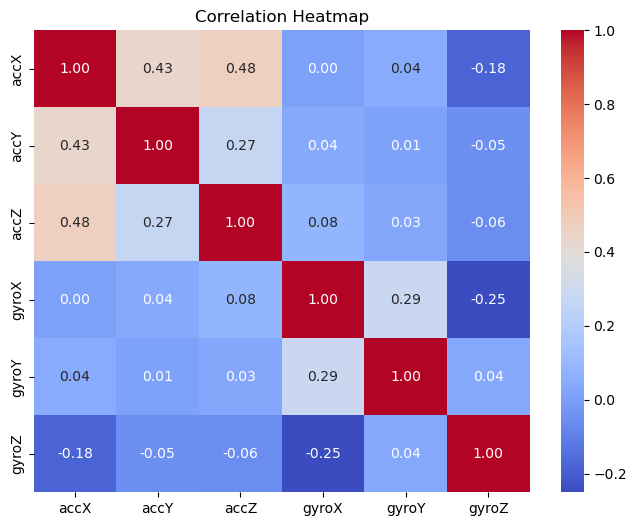

In [125]:

# Correlation matrix
corr_matrix = df[['accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']].corr()

# Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Heatmap")
plt.show()


###### heatmap that shows the correlation between different sensor readings (accX, accY, accZ, gyroX, gyroY, gyroZ). The values in the heatmap represent how strongly each pair of variables is related, with color intensity indicating the strength of the correlation. Positive correlations are shown in warmer colors (closer to 1), while negative correlations are shown in cooler colors (closer to -1). The numbers in each cell provide the exact correlation coefficient.

### 3D Scatter Plot (for accelerometer or gyroscope data)

In [126]:
# Convert timestamp to numeric values (e.g., Unix time)
df['timestamp_numeric'] = df['timestamp'].apply(lambda x: x.timestamp())

# Create a 3D scatter plot
fig_3d_acc = go.Figure(data=[go.Scatter3d(
    x=df['accX'],
    y=df['accY'],
    z=df['accZ'],
    mode='markers',
    marker=dict(
        size=5,
        color=df['timestamp_numeric'],  # Use the numeric timestamp
        colorscale='Viridis',
        colorbar=dict(title="Timestamp")
    )
)])

# Update layout and show the plot
fig_3d_acc.update_layout(title="3D Accelerometer Data")
fig_3d_acc.show()


###### This graph generates a 3D scatter plot of accelerometer data (accX, accY, accZ) over time. Each point in the plot represents a data point from the accelerometer readings, with the x, y, and z axes representing the three accelerometer measurements (accX, accY, accZ). The color of each point corresponds to the timestamp of that data point, with a color gradient (based on the numeric timestamp) representing how the data evolves over time. The colorbar indicates the range of timestamps. 

### Histogram of Accelerometer and Gyroscope Values

In [127]:
fig_hist_acc = px.histogram(df, x='accX', title="Distribution of Accelerometer X Values")
fig_hist_acc.show()

fig_hist_gyro = px.histogram(df, x='gyroX', title="Distribution of Gyroscope X Values")
fig_hist_gyro.show()


###### help to assess the range, frequency, and variability of sensor data in their respective axes, providing insight into the sensor's behavior and performance over the recorded period.

### Box Plot for Data Distribution

###### box plots provide a clear view of the distribution, variability, and potential outliers in the accelerometer and gyroscope data across different axes.

In [128]:
fig_box_acc = px.box(df, y=['accX', 'accY', 'accZ'], title="Box Plot for Accelerometer Data")
fig_box_acc.show()

fig_box_gyro = px.box(df, y=['gyroX', 'gyroY', 'gyroZ'], title="Box Plot for Gyroscope Data")
fig_box_gyro.show()


### Rolling Average Plot

In [129]:
df['accX_rolling'] = df['accX'].rolling(window=10).mean()

fig_rolling_avg = px.line(df, x='timestamp', y='accX_rolling', title="Rolling Average of Accelerometer X")
fig_rolling_avg.show()


###### This graph calculates the rolling average of the 'accX' (Accelerometer X) data with a window of 10 data points, and then visualizes it over time to smooth out short-term fluctuations and highlight longer-term trends in the accelerometer data.

### Pair Plot

In [130]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="seaborn")


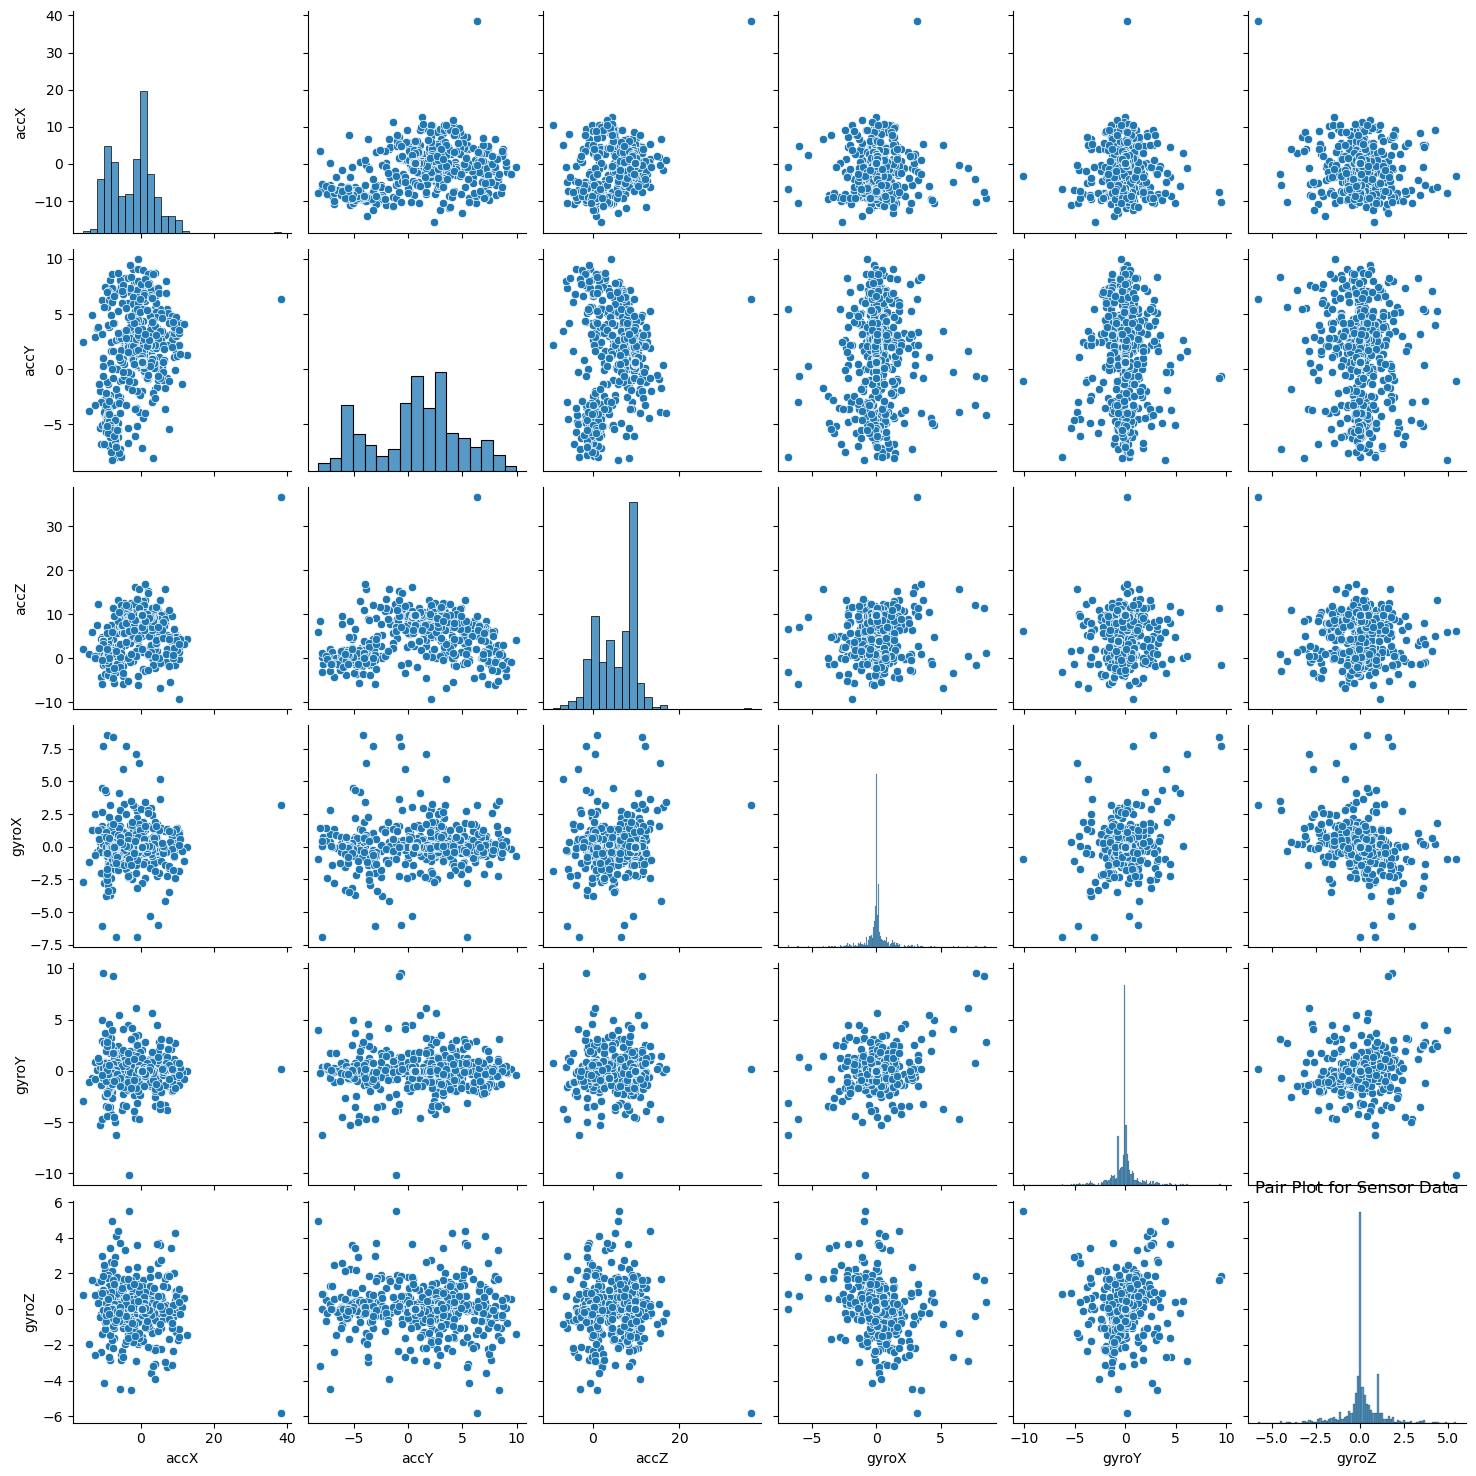

In [131]:
### import seaborn as sns
sns.pairplot(df[['accX', 'accY', 'accZ', 'gyroX', 'gyroY', 'gyroZ']])
plt.title("Pair Plot for Sensor Data")
plt.show()


###### This graph is a pair plot that visualizes the relationships between different sensor data (accX, accY, accZ, gyroX, gyroY, gyroZ) by plotting scatter plots for each pair of variables. It helps in understanding the correlations and patterns between the accelerometer and gyroscope data in the dataset.









### Velocity/Acceleration Over Time

In [132]:
# Assuming df has time intervals and accelerometer data
df['acceleration'] = np.sqrt(df['accX']**2 + df['accY']**2 + df['accZ']**2)
fig_accel = px.line(df, x='timestamp', y='acceleration', title="Acceleration Over Time")
fig_accel.show()


###### This plot shows the acceleration over time, calculated by combining the accelerometer data from the x, y, and z axes. It represents the total acceleration experienced by the device at each timestamp, helping to visualize variations in the device's movement or activity.

### Polar Plot for Gyroscope Data

In [133]:
fig_polar = go.Figure(go.Scatterpolar(
    r=df['gyroX'],
    theta=df['gyroY'],
    mode='markers',
    marker=dict(size=5, color=df['gyroZ'], colorscale='Viridis', colorbar=dict(title="Gyroscope Z"))
))
fig_polar.update_layout(title="Polar Plot for Gyroscope Data")
fig_polar.show()


###### The polar plot visualizes gyroscope data, mapping gyroX to the radius, gyroY to the angle, and using gyroZ for color intensity.

### Time vs Frequency Domain (Fourier Transform)

In [134]:
# Apply Fourier Transform to accelerometer data
accel_signal = df['accX'].values
fft_values = fft(accel_signal)

# Plot frequency vs amplitude
fig_fft = px.line(x=np.abs(fft_values), title="Fourier Transform of Accelerometer X")
fig_fft.show()


###### This plot shows the frequency vs amplitude of the accelerometer X data, revealing the frequency components of the signal after applying the Fourier Transform.